In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os
from google.colab import files

Saving de5a3eee399dd05d443048b3b3c44d1d.jpg to de5a3eee399dd05d443048b3b3c44d1d.jpg

===== MAIN MENU =====
1 Geometric Transformations
2 Image Filters
0 Exit
Enter choice: 1

--- Geometric Transformations ---
1 Translation
2 Rotation
3 Scaling
4 Shearing
5 Affine
0 Exit
Enter choice: 1
Enter tx: 23
Enter ty: 32


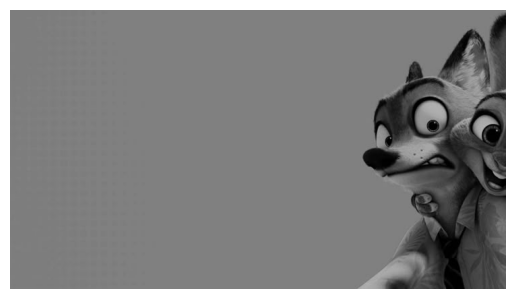


--- Geometric Transformations ---
1 Translation
2 Rotation
3 Scaling
4 Shearing
5 Affine
0 Exit
Enter choice: 2
Enter angle: 30


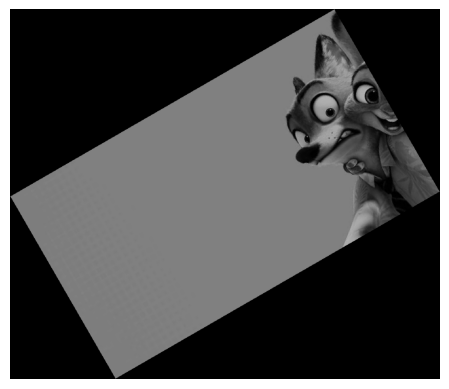


--- Geometric Transformations ---
1 Translation
2 Rotation
3 Scaling
4 Shearing
5 Affine
0 Exit
Enter choice: 3
Enter scale x: 2
Enter scale y: 2


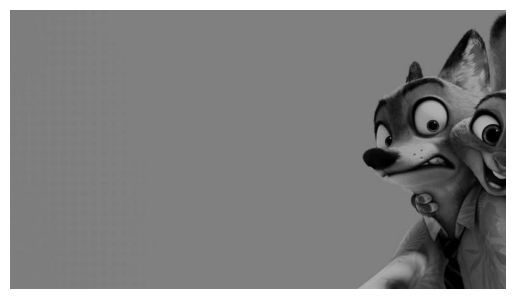


--- Geometric Transformations ---
1 Translation
2 Rotation
3 Scaling
4 Shearing
5 Affine
0 Exit
Enter choice: 4
Enter shear x: 23
Enter shear y: 23


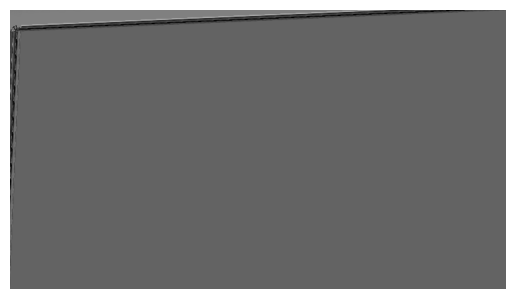


--- Geometric Transformations ---
1 Translation
2 Rotation
3 Scaling
4 Shearing
5 Affine
0 Exit
Enter choice: 0

===== MAIN MENU =====
1 Geometric Transformations
2 Image Filters
0 Exit
Enter choice: 2

--- Image Filters ---
1 Point Filter Downscale (1/9)
2 Upscale by 5
3 Mean Filter
4 Median Filter
5 Gaussian Filter
6 Sobel Edge Detection
0 Exit
Enter choice: 1
point_downscale


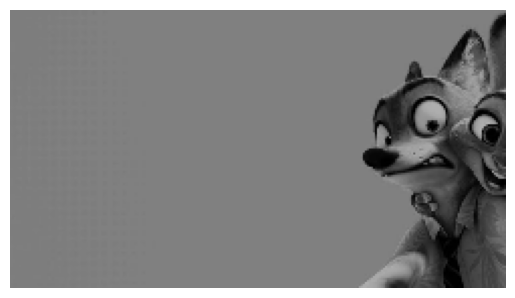


--- Image Filters ---
1 Point Filter Downscale (1/9)
2 Upscale by 5
3 Mean Filter
4 Median Filter
5 Gaussian Filter
6 Sobel Edge Detection
0 Exit
Enter choice: 2
upscale


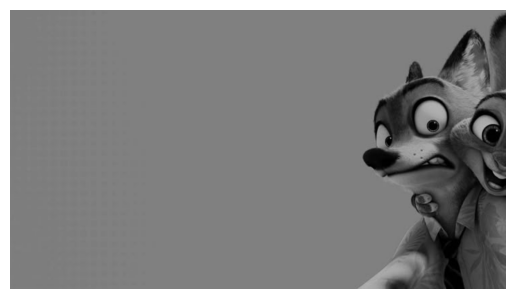


--- Image Filters ---
1 Point Filter Downscale (1/9)
2 Upscale by 5
3 Mean Filter
4 Median Filter
5 Gaussian Filter
6 Sobel Edge Detection
0 Exit
Enter choice: 3
mean_filter


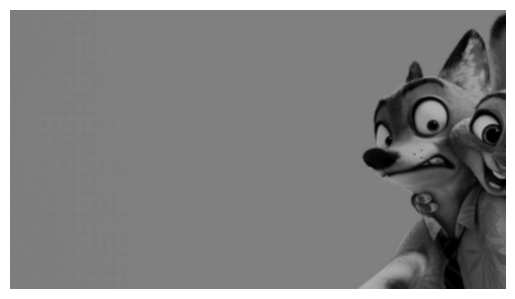


--- Image Filters ---
1 Point Filter Downscale (1/9)
2 Upscale by 5
3 Mean Filter
4 Median Filter
5 Gaussian Filter
6 Sobel Edge Detection
0 Exit
Enter choice: 4
median_filter


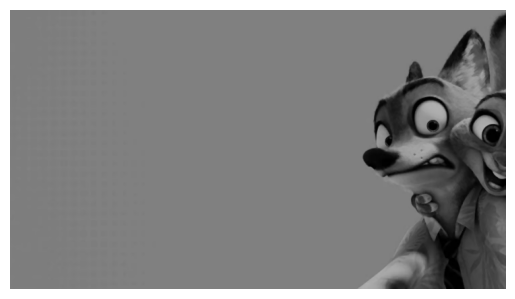


--- Image Filters ---
1 Point Filter Downscale (1/9)
2 Upscale by 5
3 Mean Filter
4 Median Filter
5 Gaussian Filter
6 Sobel Edge Detection
0 Exit
Enter choice: 5
gaussian_filter


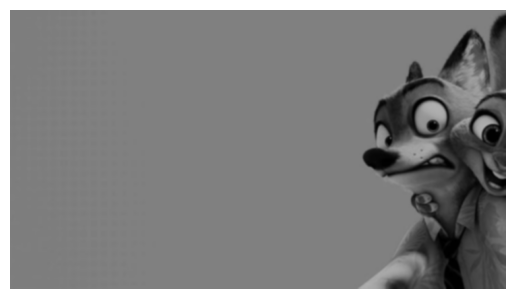


--- Image Filters ---
1 Point Filter Downscale (1/9)
2 Upscale by 5
3 Mean Filter
4 Median Filter
5 Gaussian Filter
6 Sobel Edge Detection
0 Exit
Enter choice: 6
sobel_filter


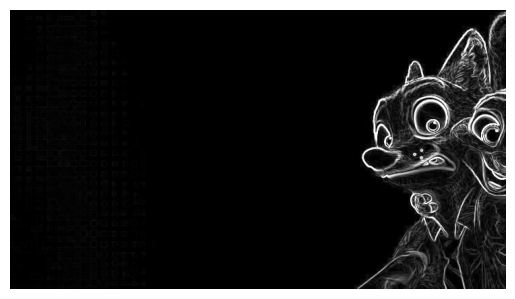


--- Image Filters ---
1 Point Filter Downscale (1/9)
2 Upscale by 5
3 Mean Filter
4 Median Filter
5 Gaussian Filter
6 Sobel Edge Detection
0 Exit
Enter choice: 0

===== MAIN MENU =====
1 Geometric Transformations
2 Image Filters
0 Exit
Enter choice: 0


In [2]:
# ---------------- GEOMETRIC TRANSFORMATIONS ----------------
class GeometricTransformer:

    def __init__(self, image_path):
        self.img_pil = Image.open(image_path)
        self.image_path = image_path
        self.img_cv = cv2.imread(image_path)

    def translate(self, tx, ty):

        width, height = self.img_pil.size
        new_img = Image.new("RGB",(width + abs(tx)*2,height + abs(ty)*2),(255,255,255))
        new_img.paste(self.img_pil,(abs(tx),abs(ty)))
        translated = new_img.crop((tx,ty,tx+width,ty+height))

        return translated


    def rotate(self, angle):

        return self.img_pil.rotate(angle,expand=True)


    def scale(self, sx, sy):

        w,h = self.img_pil.size
        return self.img_pil.resize((int(w*sx),int(h*sy)),Image.LANCZOS)


    def shear(self, shx, shy):

        img = np.array(self.img_pil)
        h,w = img.shape[:2]

        x = np.arange(w)
        y = np.arange(h)

        X,Y = np.meshgrid(x,y)

        shear_x = np.clip(X + shx*Y,0,w-1).astype(int)
        shear_y = np.clip(Y + shy*X,0,h-1).astype(int)

        result = img[shear_y,shear_x]

        return Image.fromarray(result)

    def affine(self):

      img = self.img_cv
      rows, cols = img.shape[:2]

      pts1 = np.float32([[50,50],[200,50],[50,200]])
      pts2 = np.float32([[10,100],[200,50],[100,250]])

      matrix = cv2.getAffineTransform(pts1, pts2)

      result = cv2.warpAffine(img, matrix, (cols, rows))

      return result



    def menu(self):

        while True:

            print("\n--- Geometric Transformations ---")
            print("1 Translation")
            print("2 Rotation")
            print("3 Scaling")
            print("4 Shearing")
            print("5 Affine")
            print("0 Exit")

            ch=int(input("Enter choice: "))

            if ch==0:
                break

            elif ch==1:
                tx=int(input("Enter tx: "))
                ty=int(input("Enter ty: "))
                result=self.translate(tx,ty)

            elif ch==2:
                angle=int(input("Enter angle: "))
                result=self.rotate(angle)

            elif ch==3:
                sx=int(input("Enter scale x: "))
                sy=int(input("Enter scale y: "))
                result=self.scale(sx,sy)

            elif ch==4:
                shx=int(input("Enter shear x: "))
                shy=int(input("Enter shear y: "))
                result=self.shear(shx,shy)

            elif ch==5:
                result=self.affine()
                plt.imshow(cv2.cvtColor(result,cv2.COLOR_BGR2RGB))

            else:
                print("Invalid choice")
                continue

            plt.imshow(result)
            plt.axis("off")
            plt.show()



# ---------------- FILTER OPERATIONS ----------------
class ImageFilters:

    def __init__(self,image_path):
        self.img=cv2.imread(image_path)

    # 1 Point Filter Downscale
    def point_downscale(self):
        print("point_downscale")
        img=np.array(self.img)

        downscaled=img[::3,::3]

        return downscaled


    # 2 Upscale by 5
    def upscale(self):
        print("upscale")
        h,w=self.img.shape[:2]

        return cv2.resize(self.img,(w*5,h*5),interpolation=cv2.INTER_NEAREST)


    # 3 Mean Filter
    def mean_filter(self):
        print("mean_filter")
        kernel=np.ones((3,3),np.float32)/9

        return cv2.filter2D(self.img,-1,kernel)


    # 4 Median Filter
    def median_filter(self):
        print("median_filter")
        return cv2.medianBlur(self.img,3)

    # 5 Gaussian Filter
    def gaussian_filter(self):
        print("gaussian_filter")
        return cv2.GaussianBlur(self.img,(5,5),0)


    # 6 Sobel Filter
    def sobel_filter(self):
        print("sobel_filter")
        gray=cv2.cvtColor(self.img,cv2.COLOR_BGR2GRAY)

        sobelx=cv2.Sobel(gray,cv2.CV_64F,1,0,ksize=3)
        sobely=cv2.Sobel(gray,cv2.CV_64F,0,1,ksize=3)
        sobel=cv2.magnitude(sobelx,sobely)
        sobel = cv2.convertScaleAbs(sobel)


        return sobel


    def menu(self):

        while True:

            print("\n--- Image Filters ---")
            print("1 Point Filter Downscale (1/9)")
            print("2 Upscale by 5")
            print("3 Mean Filter")
            print("4 Median Filter")
            print("5 Gaussian Filter")
            print("6 Sobel Edge Detection")
            print("0 Exit")

            ch=int(input("Enter choice: "))

            if ch==0:
                break

            elif ch==1:
                result=self.point_downscale()

            elif ch==2:
                result=self.upscale()

            elif ch==3:
                result=self.mean_filter()

            elif ch==4:
                result=self.median_filter()

            elif ch==5:
                result=self.gaussian_filter()

            elif ch==6:
                result=self.sobel_filter()

            else:
                print("Invalid choice")
                continue

            if len(result.shape) == 3:
              plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
            else:
              plt.imshow(result, cmap='gray')
            plt.axis("off")
            plt.show()



# ---------------- IMAGE UPLOAD ----------------

uploaded=files.upload()

for filename in uploaded.keys():
    full_path=os.path.abspath(filename)



# ---------------- MAIN MENU ----------------

while True:

    print("\n===== MAIN MENU =====")
    print("1 Geometric Transformations")
    print("2 Image Filters")
    print("0 Exit")

    choice=int(input("Enter choice: "))

    if choice==0:
        break

    elif choice==1:
        obj=GeometricTransformer(full_path)
        obj.menu()

    elif choice==2:
        obj=ImageFilters(full_path)
        obj.menu()

    else:
        print("Invalid choice")